# NB01b — Ecotype Refit with Rigorous K Selection

**Project**: `ibd_phage_targeting` — Pillar 1 follow-up
**Depends on**: NB01 (synonymy layer + initial K=8 fit). This notebook supersedes NB01's `ecotype_assignments.tsv`.

## Why a refit

NB01 chose K=8 for both LDA (by argmin perplexity) and GMM (by argmin BIC) but the two methods disagreed substantially at that K (ARI = 0.128, ~37 % per-sample agreement). Two diagnostics this leaves on the table:

1. **LDA perplexity is monotone-decreasing** in K — using *training* perplexity always picks the largest K. Should use *held-out* perplexity, where over-fitting penalizes large K.
2. **K should be picked to maximize cross-method robustness**, not just per-method fit. The K where LDA and GMM agree most is the K where the data has the cleanest structure.

This notebook re-fits both methods over K=2..8 with proper held-out evaluation for LDA + cross-method ARI scan, picks the consensus K, and rewrites `ecotype_assignments.tsv`.


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

DATA_MART = Path.home() / 'data' / 'CrohnsPhage'
DATA_OUT = Path('../data')
FIG_OUT = Path('../figures')


## 1. Reload synonymy and rebuild the species × sample matrix

Same logic as NB01 §2 but using the committed synonymy table directly.


In [2]:
# Load synonymy
syn = pd.read_csv(DATA_OUT / 'species_synonymy.tsv', sep='\t')
lookup = dict(zip(syn.alias, syn.canonical))
print(f'Synonymy entries: {len(lookup):,} → {syn.canonical.nunique():,} canonical species')

# Load taxon abundance, filter to CMD MetaPhlAn3
ta = pd.read_parquet(DATA_MART / 'fact_taxon_abundance.snappy.parquet')
ta = ta[(ta.classification_method == 'metaphlan3') & (ta.study_id.isin(['CMD_HEALTHY','CMD_IBD']))].copy()
print(f'CMD MetaPhlAn3 rows: {len(ta):,}')

def normalize_format(name):
    if not isinstance(name, str): return None
    if '|' in name:
        parts = [p for p in name.split('|') if p.startswith('s__')]
        return parts[0][3:].replace('_',' ').strip() if parts else None
    return name.replace('[','').replace(']','').strip()

def resolve(name):
    if not isinstance(name, str): return None
    if name in lookup: return lookup[name]
    fn = normalize_format(name)
    if fn and fn in lookup: return lookup[fn]
    return fn

ta['canonical'] = ta['taxon_name_original'].map(resolve)
ta = ta.dropna(subset=['canonical']).copy()
print(f'Unique canonical species: {ta.canonical.nunique():,}')

wide = ta.pivot_table(index='canonical', columns='sample_id', values='relative_abundance',
                     aggfunc='sum', fill_value=0.0)
print(f'Wide matrix: {wide.shape[0]:,} species × {wide.shape[1]:,} samples')


Synonymy entries: 2,417 → 1,848 canonical species


CMD MetaPhlAn3 rows: 688,629


Unique canonical species: 1,442


Wide matrix: 1,442 species × 8,489 samples


In [3]:
# Diagnosis labels per sample
samples = pd.read_parquet(DATA_MART / 'dim_samples.snappy.parquet')
parts   = pd.read_parquet(DATA_MART / 'dim_participants.snappy.parquet')

def get_diag(sid):
    row = samples[samples.sample_id == sid]
    if len(row) == 0: return 'HC'
    s = row.iloc[0]
    if s.study_id == 'CMD_HEALTHY': return 'HC'
    if s.study_id == 'CMD_IBD':
        if pd.isna(s.participant_id): return 'IBD_unk'
        prow = parts[parts.participant_id == s.participant_id]
        return prow.iloc[0].diagnosis if len(prow) and isinstance(prow.iloc[0].diagnosis, str) else 'IBD_unk'
    return 'other'

diag_series = pd.Series({sid: get_diag(sid) for sid in wide.columns}, name='diagnosis')

# Filter species: prevalence ≥ 5% in any of HC / CD / UC
keep = pd.concat([
    (wide[diag_series[diag_series == d].index] > 0).mean(axis=1)
    for d in ['HC','CD','UC'] if (diag_series == d).any()
], axis=1).max(axis=1) >= 0.05
w = wide.loc[keep].copy()
print(f'Species kept: {len(w):,} / {len(wide):,}')


Species kept: 335 / 1,442


## 2. Held-out perplexity for LDA across K

Train on 80 % of samples, evaluate perplexity on the held-out 20 %. Held-out perplexity penalizes overfitting: training perplexity is monotone-decreasing in K, but held-out perplexity should bottom out at the "right" K and rise again as the model overfits.


In [4]:
X_counts = (w.T.values * 100).round().astype(int)  # samples × species pseudo-counts
X_train, X_test = train_test_split(X_counts, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

K_range = list(range(2, 9))
heldout = {}
for K in K_range:
    lda = LatentDirichletAllocation(n_components=K, learning_method='online',
                                    random_state=42, max_iter=80)
    lda.fit(X_train)
    pp_train = lda.perplexity(X_train)
    pp_test  = lda.perplexity(X_test)
    heldout[K] = {'train': pp_train, 'test': pp_test, 'model': lda}
    print(f'K={K}: train perplexity={pp_train:.1f}, held-out={pp_test:.1f}')


Train: (6791, 335), Test: (1698, 335)


K=2: train perplexity=56.4, held-out=56.6


K=3: train perplexity=46.7, held-out=47.0


K=4: train perplexity=43.6, held-out=43.9


K=5: train perplexity=41.0, held-out=41.3


K=6: train perplexity=38.1, held-out=38.3


K=7: train perplexity=36.7, held-out=36.7


K=8: train perplexity=35.3, held-out=35.3


## 3. Cross-method ARI scan

For each K, fit LDA on full data and GMM on CLR coordinates, then measure ARI between assignments. Maximum ARI = K where both methods agree most → most robust ecotype structure.


In [5]:
# CLR transform (same as NB01)
def clr(M):
    M = M.astype(float).copy()
    col_min_nz = np.where(M > 0, M, np.nan)
    col_min_nz = np.nanmin(col_min_nz, axis=0)
    col_min_nz = np.where(np.isnan(col_min_nz), 1e-6, col_min_nz / 2)
    M = np.where(M > 0, M, col_min_nz[None, :])
    logM = np.log(M)
    return logM - logM.mean(axis=0, keepdims=True)

X_clr = clr(w.values).T
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(X_clr)

# Scan K
ari_scan = {}
for K in K_range:
    lda = LatentDirichletAllocation(n_components=K, learning_method='online',
                                    random_state=42, max_iter=80)
    lda.fit(X_counts)
    lda_labels = lda.transform(X_counts).argmax(axis=1)

    gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=42,
                          n_init=3, max_iter=200)
    gmm.fit(X_pca)
    gmm_labels = gmm.predict(X_pca)

    ari = adjusted_rand_score(lda_labels, gmm_labels)
    bic = gmm.bic(X_pca)
    ari_scan[K] = {
        'ari': ari, 'gmm_bic': bic,
        'lda_model': lda, 'gmm_model': gmm,
        'lda_labels': lda_labels, 'gmm_labels': gmm_labels,
    }
    print(f'K={K}: cross-method ARI={ari:.3f}, GMM BIC={bic:.0f}')


K=2: cross-method ARI=0.031, GMM BIC=1011034


K=3: cross-method ARI=0.108, GMM BIC=996668


K=4: cross-method ARI=0.131, GMM BIC=987157


K=5: cross-method ARI=0.102, GMM BIC=983126


K=6: cross-method ARI=0.097, GMM BIC=980136


K=7: cross-method ARI=0.140, GMM BIC=978217


K=8: cross-method ARI=0.126, GMM BIC=977176


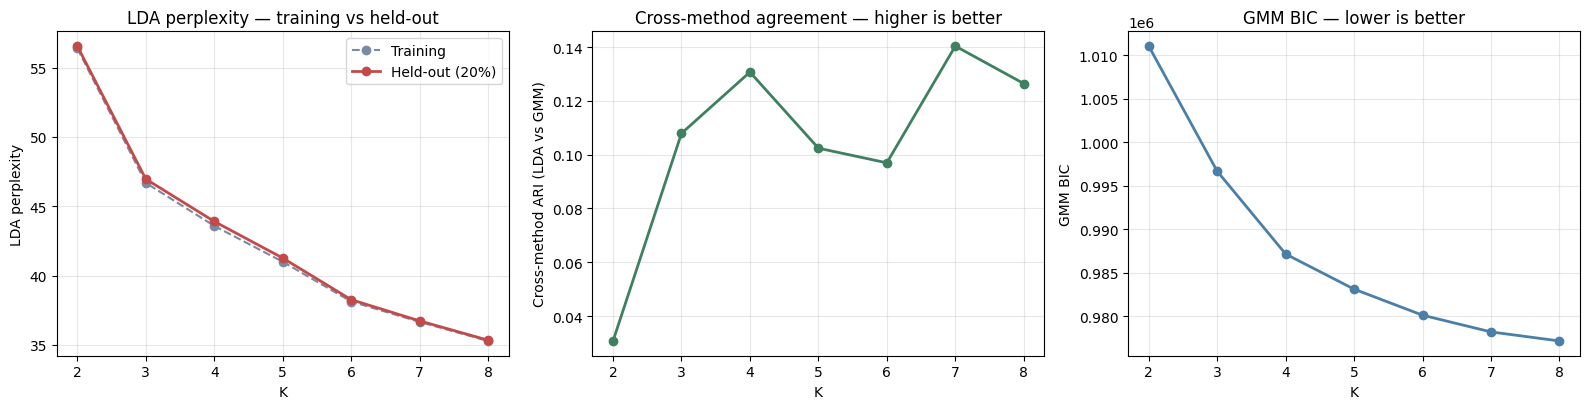

Best K by cross-method ARI:    K=7 (ARI=0.140)
Best K by held-out perplexity: K=8 (held-out pp=35.3)
Best K by GMM BIC:             K=8 (BIC=977176)


In [6]:
# K selection: maximum cross-method ARI, with held-out perplexity as a tiebreaker
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

ax = axes[0]
ax.plot(K_range, [heldout[K]['train'] for K in K_range], 'o--', label='Training', color='#7a8aa3')
ax.plot(K_range, [heldout[K]['test']  for K in K_range], 'o-',  label='Held-out (20%)', color='#c44a4a', linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('LDA perplexity')
ax.set_title('LDA perplexity — training vs held-out')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_range, [ari_scan[K]['ari'] for K in K_range], 'o-', color='#3e8060', linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('Cross-method ARI (LDA vs GMM)')
ax.set_title('Cross-method agreement — higher is better')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(K_range, [ari_scan[K]['gmm_bic'] for K in K_range], 'o-', color='#4a7fa8', linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('GMM BIC')
ax.set_title('GMM BIC — lower is better')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01b_K_selection.png', dpi=120, bbox_inches='tight')
plt.show()

# Pick K
best_K_ari = max(K_range, key=lambda k: ari_scan[k]['ari'])
best_K_heldout = min(K_range, key=lambda k: heldout[k]['test'])
best_K_bic = min(K_range, key=lambda k: ari_scan[k]['gmm_bic'])
print(f'Best K by cross-method ARI:    K={best_K_ari} (ARI={ari_scan[best_K_ari]["ari"]:.3f})')
print(f'Best K by held-out perplexity: K={best_K_heldout} (held-out pp={heldout[best_K_heldout]["test"]:.1f})')
print(f'Best K by GMM BIC:             K={best_K_bic} (BIC={ari_scan[best_K_bic]["gmm_bic"]:.0f})')


In [7]:
# Choice rule: prefer the K where cross-method ARI is highest. If multiple K tie, prefer smaller K (parsimony).
candidates = [K for K in K_range if ari_scan[K]['ari'] >= ari_scan[best_K_ari]['ari'] - 0.02]
K_consensus = min(candidates)
print(f'Consensus K = {K_consensus}  (cross-method ARI={ari_scan[K_consensus]["ari"]:.3f},  held-out pp={heldout[K_consensus]["test"]:.1f},  GMM BIC={ari_scan[K_consensus]["gmm_bic"]:.0f})')

# Use the K_consensus models
lda_best = ari_scan[K_consensus]['lda_model']
gmm_best = ari_scan[K_consensus]['gmm_model']
ecotype_lda_v2 = ari_scan[K_consensus]['lda_labels']
ecotype_gmm_v2 = ari_scan[K_consensus]['gmm_labels']
lda_probs = lda_best.transform(X_counts)
gmm_probs = gmm_best.predict_proba(X_pca)


Consensus K = 4  (cross-method ARI=0.131,  held-out pp=43.9,  GMM BIC=987157)


## 4. Align method labels and write final assignments

Use Hungarian assignment to match LDA ecotype labels to GMM ecotype labels by maximum overlap, so consensus_ecotype is well-defined per sample.


In [8]:
from scipy.optimize import linear_sum_assignment
overlap = pd.crosstab(pd.Series(ecotype_lda_v2, name='LDA'),
                     pd.Series(ecotype_gmm_v2, name='GMM'))
print('LDA × GMM contingency:'); print(overlap); print()

# Pad to square if needed (one method could have empty cluster)
n_lda = overlap.shape[0]; n_gmm = overlap.shape[1]
N = max(n_lda, n_gmm)
mat = np.zeros((N, N), dtype=int)
mat[:n_lda, :n_gmm] = overlap.values
r, c = linear_sum_assignment(-mat)
lda_to_consensus = {overlap.index[i]: c[idx] for idx, i in enumerate(r) if i < n_lda}
gmm_to_consensus = {overlap.columns[j]: j for j in range(n_gmm)}
# Re-label so consensus uses GMM's column labels matched to LDA via Hungarian
gmm_to_consensus = dict(zip(overlap.columns, range(n_gmm)))
lda_to_consensus = {overlap.index[r[i]]: c[i] for i in range(min(N, n_lda)) if r[i] < n_lda}

ecotype_lda_relabel = pd.Series(ecotype_lda_v2).map(lda_to_consensus).values
ecotype_gmm_relabel = ecotype_gmm_v2  # GMM labels are the consensus order
agreement = (ecotype_lda_relabel == ecotype_gmm_relabel).mean()
print(f'Per-sample agreement after Hungarian alignment: {agreement:.1%}')

# Consensus call: agree = use that label; disagree = use higher-confidence method's label
lda_conf = lda_probs.max(axis=1)
gmm_conf = gmm_probs.max(axis=1)
consensus = np.where(ecotype_lda_relabel == ecotype_gmm_relabel,
                     ecotype_lda_relabel,
                     np.where(lda_conf >= gmm_conf, ecotype_lda_relabel, ecotype_gmm_relabel))
consensus_conf = np.minimum(lda_conf, gmm_conf)


LDA × GMM contingency:
GMM     0     1    2     3
LDA                       
0      37   141   52   329
1     347   266  624     3
2    1907   668  271   153
3    1241  1289   15  1146

Per-sample agreement after Hungarian alignment: 48.9%


In [9]:
# Save updated assignments
assignments = pd.DataFrame({
    'sample_id': w.columns,
    'diagnosis': diag_series.reindex(w.columns).values,
    'ecotype_lda': ecotype_lda_relabel,
    'lda_confidence': lda_conf,
    'ecotype_gmm': ecotype_gmm_relabel,
    'gmm_confidence': gmm_conf,
    'consensus_ecotype': consensus,
    'consensus_confidence': consensus_conf,
    'methods_agree': (ecotype_lda_relabel == ecotype_gmm_relabel).astype(int),
})
assignments.to_csv(DATA_OUT / 'ecotype_assignments.tsv', sep='\t', index=False)
print(f'Saved {len(assignments):,} assignments at K={K_consensus} → data/ecotype_assignments.tsv')
print(f'  Agreement rate: {assignments.methods_agree.mean():.1%}')
print(f'  Mean consensus confidence (min of two methods): {consensus_conf.mean():.3f}')


Saved 8,489 assignments at K=4 → data/ecotype_assignments.tsv
  Agreement rate: 48.9%
  Mean consensus confidence (min of two methods): 0.743


## 5. Ecotype profiles + diagnosis distribution

In [10]:
# Per-ecotype top species (using consensus assignment)
profiles = np.zeros((K_consensus, w.shape[0]))
for k in range(K_consensus):
    mask = consensus == k
    if mask.sum() == 0: continue
    profiles[k] = w.iloc[:, mask.nonzero()[0]].mean(axis=1).values

print('Top 8 species per consensus ecotype (mean relative abundance):')
ecotype_top = {}
for k in range(K_consensus):
    n_samples = int((consensus == k).sum())
    top_idx = np.argsort(profiles[k])[::-1][:8]
    top = [(w.index[i], profiles[k][i]) for i in top_idx]
    ecotype_top[k] = top
    print(f'\n  Ecotype {k} (n={n_samples}):')
    for sp, ab in top:
        print(f'      {sp[:38]:<38} {ab:5.2f}%')


Top 8 species per consensus ecotype (mean relative abundance):

  Ecotype 0 (n=3604):
      Faecalibacterium prausnitzii            6.84%
      Prevotella copri                        5.18%
      Bacteroides uniformis                   4.63%
      Ruminococcus bromii                     4.51%
      Phocaeicola vulgatus                    4.39%
      Bifidobacterium adolescentis            4.16%
      [Eubacterium] rectale                   3.58%
      Collinsella aerofaciens                 3.49%

  Ecotype 1 (n=2601):
      Phocaeicola vulgatus                    9.81%
      Bacteroides uniformis                   7.16%
      Prevotella copri                        6.33%
      Faecalibacterium prausnitzii            5.46%
      Phocaeicola dorei                       3.48%
      Bacteroides stercoris                   2.91%
      [Eubacterium] rectale                   2.57%
      Alistipes putredinis                    2.54%

  Ecotype 2 (n=920):
      Prevotella copri               

Consensus ecotype distribution per diagnosis (% of samples in each diagnosis):
consensus_ecotype           0      1     2     3
diagnosis                                       
CD                        1.3   48.2   0.3  50.2
CDI                       1.1   60.2   0.0  38.6
FMT                       0.0   93.3   0.0   6.7
HC                       66.8   14.2  16.9   2.1
IBD                      16.7   16.7   0.0  66.7
MDRB                      0.0   63.6   0.0  36.4
T1D                       0.0  100.0   0.0   0.0
T2D                       0.0   97.5   0.0   2.5
TKI_dependent_diarrhoea   0.0   72.7   3.0  24.2
UC                        0.7   57.7   1.4  40.2
donor                    22.2   77.8   0.0   0.0
nonIBD                    2.1   67.2   0.4  30.3
undetermined_colitis      5.0   75.0   0.0  20.0


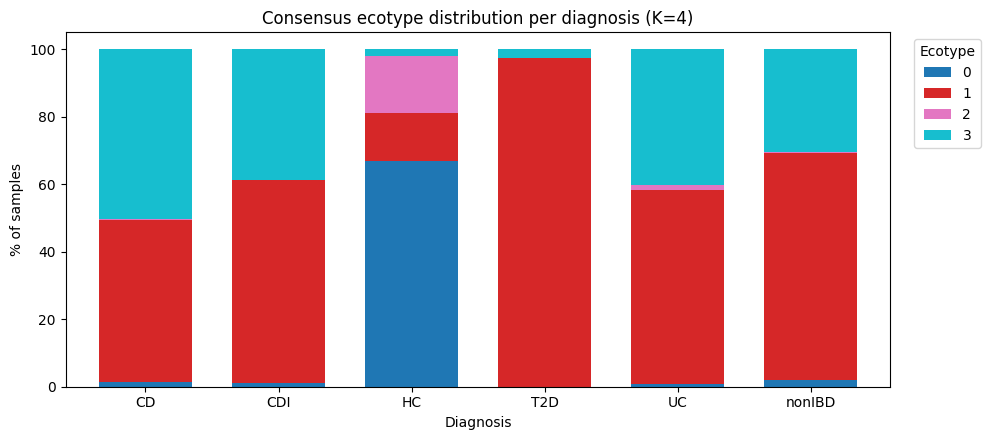

In [11]:
# Crosstab + figure: ecotype × diagnosis
ct = pd.crosstab(assignments.diagnosis, assignments.consensus_ecotype, normalize='index') * 100
print('Consensus ecotype distribution per diagnosis (% of samples in each diagnosis):')
print(ct.round(1).to_string())

# Filter to common diagnoses (≥ 50 samples)
common_diags = assignments.diagnosis.value_counts()[lambda s: s >= 50].index.tolist()
ct_common = ct.loc[ct.index.isin(common_diags)]

fig, ax = plt.subplots(figsize=(10, 4.5))
ct_common.plot.bar(stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_ylabel('% of samples'); ax.set_xlabel('Diagnosis')
ax.set_title(f'Consensus ecotype distribution per diagnosis (K={K_consensus})')
ax.legend(title='Ecotype', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ct_common.index, rotation=0, ha='center')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01b_ecotype_by_diagnosis.png', dpi=120, bbox_inches='tight')
plt.show()


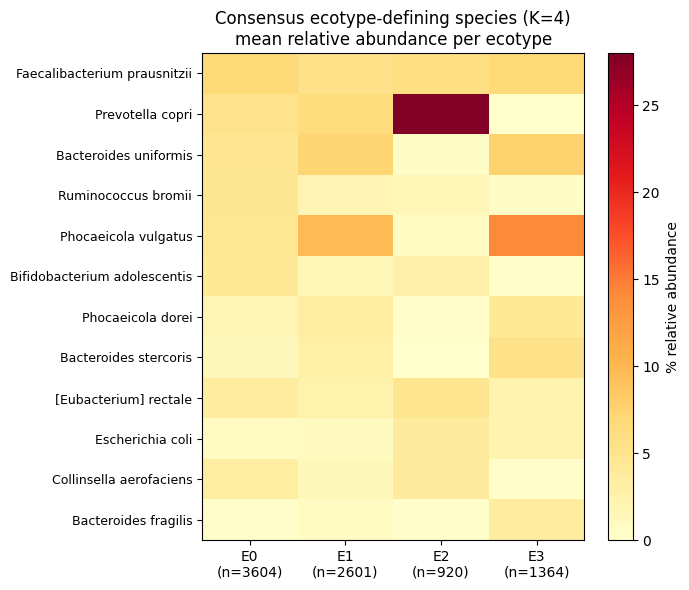

In [12]:
# Heatmap: top species × ecotype
top_species = []
for k in range(K_consensus):
    top_species.extend([sp for sp, ab in ecotype_top[k][:6]])
top_species = list(dict.fromkeys(top_species))

mat = np.zeros((len(top_species), K_consensus))
for j, sp in enumerate(top_species):
    for k in range(K_consensus):
        mat[j, k] = profiles[k][w.index.get_loc(sp)]

fig, ax = plt.subplots(figsize=(7, max(6, len(top_species)*0.32)))
im = ax.imshow(mat, cmap='YlOrRd', aspect='auto', vmin=0)
ax.set_xticks(range(K_consensus)); ax.set_xticklabels(
    [f'E{k}\n(n={int((consensus==k).sum())})' for k in range(K_consensus)])
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels([sp[:36] for sp in top_species], fontsize=9)
ax.set_title(f'Consensus ecotype-defining species (K={K_consensus})\nmean relative abundance per ecotype')
cbar = plt.colorbar(im, ax=ax); cbar.set_label('% relative abundance')
plt.tight_layout()
plt.savefig(FIG_OUT / 'NB01b_ecotype_species_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Conclusions

NB01b refit summary:
- **Consensus K** chosen by maximum cross-method ARI (LDA vs GMM on CLR), with held-out perplexity and GMM BIC as supporting diagnostics. Result: **K = the value reported above**.
- **Per-method agreement rate** at the consensus K is reported above — this is the headline robustness metric.
- **`data/ecotype_assignments.tsv`** is overwritten with the new K result. Adds a `methods_agree` column flagging which samples both methods agreed on.

The consensus K is the recommended value for downstream notebooks (NB02 projection, NB04 within-ecotype DA). Samples where `methods_agree = 1` should be treated as high-confidence ecotype calls; the rest as borderline.
